# 1.1 Exploración Inicial - Análisis Descriptivo de Datos Consolidados

## Objetivo

Este notebook realiza la **exploración descriptiva inicial** del dataset consolidado generado por `src/data/process.py`. El objetivo es validar la calidad de los datos cargados y comprender su estructura básica antes de proceder con la ingeniería de características.

## Alcance

1. **Carga de datos consolidados**: Usar el output de `process.py` (`commodities_base_consolidated.csv`)
2. **Validación de integridad**: Verificar dimensiones, tipos de datos, y cobertura temporal
3. **Análisis de valores faltantes**: Identificar patrones de missing data por variable y período
4. **Estadísticas descriptivas**: Medidas de tendencia central y dispersión
5. **Visualización de series temporales**: Gráficos de precios históricos para commodities clave
6. **Distribuciones de precios**: Histogramas para detectar asimetría y outliers

## Metodología

Este análisis es puramente **descriptivo** y **no inferencial**. Se enfoca en:
- Medidas univariadas (media, mediana, desviación estándar, cuartiles)
- Identificación visual de tendencias, estacionalidad y volatilidad
- Documentación de hallazgos para guiar decisiones en feature engineering

## Prerrequisitos

**Ejecutar antes de este notebook:**
```bash
python src/data/process.py
```

Esto genera `data/processed/commodities_base_consolidated.csv` con 99 columnas base (sin features derivadas).

In [21]:
"""
Setup - Configuración de entorno y librerías

IMPORTANTE: Este notebook debe ejecutarse DESPUÉS de `python src/data/process.py`
"""

import sys
from pathlib import Path
from IPython.display import display
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Agregar directorio raíz del proyecto al PYTHONPATH
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos del proyecto
from src.config import PROCESSED_DIR, FIGURES_DIR, START_DATE, END_DATE
from src.visualization import configurar_estilo_grafico, formatear_ejes

# Configurar estilo visual institucional (sin grids, colores UBA)
COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")
%matplotlib inline

# Configurar display de pandas para mejor legibilidad
pd.options.display.max_columns = 100
pd.options.display.max_rows = 50
pd.options.display.float_format = '{:,.2f}'.format

print("Entorno configurado correctamente")
print(f"Directorio de trabajo: {Path.cwd()}")
print(f"Directorio raíz del proyecto: {project_root}")

Entorno configurado correctamente
Directorio de trabajo: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\notebooks\1.0-exploratory
Directorio raíz del proyecto: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal


## 1. Carga y Validación de Datos Consolidados

Cargamos el dataset generado por `process.py` que contiene:
- 27 commodities en formato wide (precios OHLCV + volume)
- 14 predictores macroeconómicos (índices y tasas)
- Datos climáticos agregados (ONI + NASA POWER para 3 regiones)
- Datos de supply-demand (USDA PSD para 5 países)

**Archivo esperado:** `data/processed/commodities_base_consolidated.csv`

Este archivo contiene ~99 columnas base (sin features derivadas como lags, rolling, returns).

**IMPORTANTE - Filtro Temporal:**
- El análisis se enfoca en **datos del milenio (2000 en adelante)**
- Filtro definido en `src/config.py`: `START_DATE = '2000-01-01'`
- Datos pre-2000 son descartados automáticamente para mantener relevancia del análisis
- Esto asegura consistencia entre notebooks y módulos de procesamiento

## 0. Definición de Variables: Objetivo vs Predictores

**IMPORTANTE:** Este proyecto busca **predecir precios de commodities agrícolas** usando otros commodities, índices macro, clima y supply-demand como predictores.

**ALCANCE TEMPORAL:** Análisis enfocado en el **milenio (2000 en adelante)** para relevancia de patrones y disponibilidad de datos de calidad.

### Variables Objetivo (15 commodities agrícolas):
- **Granos**: Corn, Soybeans, Wheat, Wheat_Kansas, Oat
- **Subproductos soja**: Soybean_Meal, Soybean_Oil  
- **Softs**: Sugar, Coffee, Cocoa, Cotton
- **Otros**: Lumber
- **Ganado**: Live_Cattle, Feeder_Cattle, Lean_Hogs

### Variables Predictoras (~64 variables):
1. **Commodities no-agrícolas**:
   - Energía: Crude_Oil, Brent_Crude, Natural_Gas, Heating_Oil, RBOB_Gasoline, Ethanol
   - Metales preciosos: Gold, Silver, Platinum, Palladium
   - Metales industriales: Copper
   - Índices: Baltic_Dry_Index, Energy_Index, Materials_Index

2. **Índices macroeconómicos**:
   - Volatilidad: VIX
   - Dólar: DXY
   - Equity: SP500
   - Tasas: Treasury_2Y, Treasury_10Y, TIPS

3. **Divisas**: EUR_USD, USD_ARS, USD_BRL, USD_CNY, USD_RUB, USD_UAH

4. **Variables PSD (supply-demand)**: Producción, stocks, exportaciones, importaciones para World, Brazil, USA, Argentina, China

5. **Variables climáticas**: RH, SolarRad, WindSpeed para regiones productoras de granos

**Formato de datos**: Cada commodity tiene columnas OHLCV (Open, High, Low, Close, Volume)

**Período de análisis**: 2000-01-01 hasta presente (~25 años, ~6,500 observaciones diarias)

In [22]:
# Validar existencia del archivo consolidado
consolidated_file = PROCESSED_DIR / 'commodities_base_consolidated.csv'

if not consolidated_file.exists():
    raise FileNotFoundError(
        f"\nERROR: No se encontró el archivo {consolidated_file}\n"
        f"\nEjecuta primero:\n"
        f"  python src/data/process.py\n"
    )

# Cargar datos consolidados
print(f"Cargando datos desde: {consolidated_file}")
df = pd.read_csv(consolidated_file, parse_dates=['date'])

print(f"\nDatos cargados correctamente (sin filtrar)")
print(f"Dimensiones originales: {df.shape[0]:,} observaciones x {df.shape[1]} variables")
print(f"Período original: {df['date'].min().date()} hasta {df['date'].max().date()}")

# FILTRAR por rango temporal definido en config (START_DATE desde año 2000)
print(f"\n{'='*70}")
print(f"APLICANDO FILTRO TEMPORAL: {START_DATE} en adelante")
print(f"{'='*70}")

df = df[df['date'] >= START_DATE].copy()
df = df.reset_index(drop=True)

print(f"\nDatos filtrados al milenio (2000+)")
print(f"Dimensiones finales: {df.shape[0]:,} observaciones x {df.shape[1]} variables")
print(f"Período final: {df['date'].min().date()} hasta {df['date'].max().date()}")
print(f"Observaciones descartadas: {pd.read_csv(consolidated_file).shape[0] - df.shape[0]:,}")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

display(df.head(10))

Cargando datos desde: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\commodities_base_consolidated.csv

Datos cargados correctamente (sin filtrar)
Dimensiones originales: 6,981 observaciones x 99 variables
Período original: 1999-01-04 hasta 2025-11-10

APLICANDO FILTRO TEMPORAL: 2000-01-01 en adelante

Datos filtrados al milenio (2000+)
Dimensiones finales: 6,731 observaciones x 99 variables
Período final: 2000-01-03 hasta 2025-11-10
Observaciones descartadas: 250
Tamaño en memoria: 5.08 MB
Observaciones descartadas: 250
Tamaño en memoria: 5.08 MB


,date,Baltic_Dry_Index,Brent_Crude,Cocoa,Coffee,Copper,Corn,Cotton,Crude_Oil,Ethanol,Feeder_Cattle,Gold,Heating_Oil,Lean_Hogs,Live_Cattle,Lumber,Natural_Gas,Oat,Palladium,Platinum,RBOB_Gasoline,Silver,Soybean_Meal,Soybean_Oil,Soybeans,Sugar,Wheat,Wheat_Kansas,Baltic_Dry_Index_volume,Brent_Crude_volume,Cocoa_volume,Coffee_volume,Copper_volume,Corn_volume,Cotton_volume,Crude_Oil_volume,Ethanol_volume,Feeder_Cattle_volume,Gold_volume,Heating_Oil_volume,Lean_Hogs_volume,Live_Cattle_volume,Lumber_volume,Natural_Gas_volume,Oat_volume,Palladium_volume,Platinum_volume,RBOB_Gasoline_volume,Silver_volume,Soybean_Meal_volume,Soybean_Oil_volume,Soybeans_volume,Sugar_volume,Wheat_volume,Wheat_Kansas_volume,DXY,EUR_USD,Energy_Index,Materials_Index,SP500,TIPS,Treasury_10Y,Treasury_2Y,USD_ARS,USD_BRL,USD_CNY,USD_RUB,USD_UAH,VIX,ONI,Temp_Global_Grain,Precip_Global_Grain,RH_Global_Grain,SolarRad_Global_Grain,WindSpeed_Global_Grain,ET0_Global_Grain,GDD_Global_Grain,Heat_Stress_Days,Precip_Deficit,psd_world_Production,psd_world_Ending_Stocks,psd_world_Exports,psd_world_Imports,psd_world_Stock_to_Use_Ratio,psd_brazil_Production,psd_brazil_Ending_Stocks,psd_brazil_Exports,psd_brazil_Stock_to_Use_Ratio,psd_united_states_Production,psd_united_states_Ending_Stocks,psd_united_states_Exports,psd_united_states_Stock_to_Use_Ratio,psd_argentina_Production,psd_argentina_Exports,psd_argentina_Stock_to_Use_Ratio,psd_china_Imports,psd_china_Crush,psd_china_Ending_Stocks,psd_china_Stock_to_Use_Ratio
0,2000-01-03,NaN,NaN,830.00,116.50,NaN,NaN,51.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,426.00","6,640.00",NaN,NaN,"8,033.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.22,NaN,206.58,14.60,"1,455.22",NaN,6.55,5.27,NaN,NaN,NaN,NaN,NaN,24.21,-1.66,14.92,1.48,72.06,15.90,1.83,3.05,4.92,0.00,-82.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,"1,320.00",NaN,836.00,116.25,NaN,NaN,50.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.00,441.90,429.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,"1,957.00","5,492.00",NaN,NaN,"4,709.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.00,177.00,632.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.41,NaN,202.38,14.46,"1,399.42",NaN,6.49,5.27,NaN,NaN,NaN,NaN,NaN,27.01,-1.66,12.94,2.48,66.33,16.34,1.83,2.89,2.94,0.00,-80.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,"1,329.00",NaN,831.00,118.60,NaN,NaN,51.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.75,438.10,419.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,"3,975.00","6,165.00",NaN,NaN,"10,464.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,319.00,571.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.38,NaN,208.56,15.05,"1,402.11",NaN,6.60,5.27,NaN,NaN,NaN,NaN,NaN,26.41,-1.66,14.10,6.83,70.21,15.35,1.63,2.79,4.10,0.00,-73.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,"1,351.00",NaN,841.00,116.85,NaN,NaN,52.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.00,435.30,412.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,"3,454.00","5,094.00",NaN,NaN,"7,247.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,180.00,494.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.65,NaN,218.14,15.44,"1,403.45",NaN,6.55,5.24,NaN,NaN,NaN,NaN,NaN,25.73,-1.66,15.04,3.52,72.92,13.42,1.36,2.08,5.04,0.00,-70.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,"1,368.00",NaN,853.00,114.15,NaN,NaN,53.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.25,443.90,414.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,"5,008.00","6,855.00",NaN,NaN,"19,389.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,102.00,130.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.80,NaN,220.85,15.43,"1,441.47",NaN,6.50,5.22,NaN,NaN,NaN,NaN,NaN,21.72,-1.66,14.80,1.61,72.62,14.95,1.44,2.48,4.80,0.00,-68.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2000-01-10,"1,376.00",NaN,839.00,117.55,NaN,NaN,53.56,NaN,Na

In [23]:
# Información general del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*70)

print(f"\nTipos de datos por variable:")
print(df.dtypes.value_counts())

print(f"\n\nRango temporal:")
print(f"  Fecha mínima: {df['date'].min()}")
print(f"  Fecha máxima: {df['date'].max()}")
print(f"  Días totales: {(df['date'].max() - df['date'].min()).days:,}")
print(f"  Observaciones: {len(df):,}")

print(f"\n\nEstructura de columnas:")
df_info = pd.DataFrame({
    'Columna': df.columns,
    'Tipo': df.dtypes.values,
    'Non-Null': df.count().values,
    'Missing': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values
})
display(df_info)

INFORMACIÓN GENERAL DEL DATASET

Tipos de datos por variable:
float64           98
datetime64[ns]     1
Name: count, dtype: int64


Rango temporal:
  Fecha mínima: 2000-01-03 00:00:00
  Fecha máxima: 2025-11-10 00:00:00
  Días totales: 9,443
  Observaciones: 6,731


Estructura de columnas:


,Columna,Tipo,Non-Null,Missing,Missing %
0,date,datetime64[ns],6731,0,0.00
1,Baltic_Dry_Index,float64,6456,275,4.09
2,Brent_Crude,float64,4550,2181,32.40
3,Cocoa,float64,6485,246,3.65
4,Coffee,float64,6483,248,3.68
...,...,...,...,...,...
94,psd_argentina_Stock_to_Use_Ratio,float64,6559,172,2.56
95,psd_china_Imports,float64,6559,172,2.56
96,psd_china_Crush,float64,6559,172,2.56
97,psd_china_Ending_Stocks,float64,6559,172,2.56


In [24]:
# RESUMEN VISUAL: Clasificación de variables objetivo vs predictores

# Definir commodities agrícolas (objetivo)
AGRICULTURAL_COMMODITIES = [
    'Corn', 'Soybeans', 'Wheat', 'Wheat_Kansas', 'Oat',
    'Soybean_Meal', 'Soybean_Oil', 'Sugar', 'Coffee', 'Cocoa',
    'Cotton', 'Lumber', 'Live_Cattle', 'Feeder_Cattle', 'Lean_Hogs'
]

# Identificar columnas agrícolas en el dataset
agri_cols = [col for col in df.columns 
             if any(agri in col for agri in AGRICULTURAL_COMMODITIES) and col != 'date']

# PREDICTORES: Todo lo demás
predictor_cols = [col for col in df.columns 
                  if col != 'date' and col not in agri_cols]

# Crear resumen visual
print("╔" + "═"*78 + "╗")
print("║" + " "*20 + "ESTRUCTURA DEL DATASET" + " "*36 + "║")
print("╠" + "═"*78 + "╣")
print(f"║  Total de columnas: {len(df.columns):>3}                                                    ║")
print(f"║  Fecha: date                                                               ║")
print("╠" + "─"*78 + "╣")
print(f"║  VARIABLES OBJETIVO (Commodities Agrícolas): {len(set([c.split('_')[0] for c in agri_cols])):<2} commodities           ║")
print(f"║    └─ Columnas totales: {len(agri_cols):>3} (OHLCV format)                                  ║")
print(f"║    └─ Commodities: {', '.join(AGRICULTURAL_COMMODITIES[:5])}...{' ':<10}║")
print("╠" + "─"*78 + "╣")
print(f"║  PREDICTORES: {len(predictor_cols):>3} columnas                                                  ║")

# Clasificar predictores por tipo
pred_energia = [c for c in predictor_cols if any(p in c for p in ['Crude', 'Brent', 'Gas', 'Heating', 'RBOB', 'Ethanol'])]
pred_metales = [c for c in predictor_cols if any(p in c for p in ['Gold', 'Silver', 'Copper', 'Platinum', 'Palladium'])]
pred_macro = [c for c in predictor_cols if any(p in c for p in ['DXY', 'VIX', 'SP500', 'Treasury', 'TIPS', 'EUR_USD', 'USD_'])]
pred_psd = [c for c in predictor_cols if 'psd_' in c]
pred_clima = [c for c in predictor_cols if any(p in c for p in ['RH_', 'SolarRad', 'WindSpeed'])]
pred_indices = [c for c in predictor_cols if 'Index' in c]

print(f"║    ├─ Commodities energía: {len(pred_energia):>2}                                              ║")
print(f"║    ├─ Commodities metales: {len(pred_metales):>2}                                              ║")
print(f"║    ├─ Índices: {len(pred_indices):>2}                                                          ║")
print(f"║    ├─ Macro/Divisas: {len(pred_macro):>2}                                                     ║")
print(f"║    ├─ Variables PSD (supply-demand): {len(pred_psd):>2}                                        ║")
print(f"║    └─ Variables climáticas: {len(pred_clima):>2}                                               ║")
print("╚" + "═"*78 + "╝")

print(f"\n📊 DISTRIBUCIÓN DE DATOS:")
print(f"   • Observaciones: {len(df):,}")
print(f"   • Período: {df['date'].min().date()} hasta {df['date'].max().date()}")
print(f"   • Días totales: {(df['date'].max() - df['date'].min()).days:,}")

# Guardar listas para uso en celdas posteriores
print(f"\n✓ Variables clasificadas correctamente")
print(f"✓ agri_cols: {len(agri_cols)} columnas (variables objetivo)")
print(f"✓ predictor_cols: {len(predictor_cols)} columnas (para predicción)")

╔══════════════════════════════════════════════════════════════════════════════╗
║                    ESTRUCTURA DEL DATASET                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Total de columnas:  99                                                    ║
║  Fecha: date                                                               ║
╠──────────────────────────────────────────────────────────────────────────────╣
║  VARIABLES OBJETIVO (Commodities Agrícolas): 13 commodities           ║
║    └─ Columnas totales:  30 (OHLCV format)                                  ║
║    └─ Commodities: Corn, Soybeans, Wheat, Wheat_Kansas, Oat...          ║
╠──────────────────────────────────────────────────────────────────────────────╣
║  PREDICTORES:  68 columnas                                                  ║
║    ├─ Commodities energía: 12                                              ║
║    ├─ Commodities metales: 10                 

## 2. Análisis de Cobertura Temporal por Variable

**Objetivo:** Identificar el período de disponibilidad de datos para cada variable. Esto es crítico para:
- Detectar variables con cobertura limitada que podrían limitar el período de entrenamiento
- Identificar desfases temporales entre commodities y predictores
- Evaluar la necesidad de estrategias de imputación o recorte temporal

**Metodología:**
- Calcular fecha mínima, fecha máxima y conteo de observaciones válidas (non-null) por variable
- Visualizar cobertura temporal con gráficos de barras
- Identificar variables con cobertura incompleta (<90% del período total)

In [25]:
# CLASIFICACIÓN DE VARIABLES: Commodities Agrícolas (objetivo) vs Predictores

# Commodities agrícolas que queremos PREDECIR
AGRICULTURAL_COMMODITIES = [
    'Corn', 'Soybeans', 'Wheat', 'Wheat_Kansas', 'Oat',
    'Soybean_Meal', 'Soybean_Oil', 'Sugar', 'Coffee', 'Cocoa',
    'Cotton', 'Lumber', 'Live_Cattle', 'Feeder_Cattle', 'Lean_Hogs'
]

# Identificar columnas de commodities agrícolas en el dataset (pueden tener sufijos _close, _open, etc.)
agri_cols = [col for col in df.columns 
             if any(agri in col for agri in AGRICULTURAL_COMMODITIES)]

print("CLASIFICACIÓN DE VARIABLES")
print("="*70)
print(f"\nCommodities Agrícolas (Variables Objetivo): {len(set([col.split('_')[0] for col in agri_cols if col != 'date']))}")
print(f"Columnas totales: {len(agri_cols)} (incluye OHLCV)")

# Mostrar commodities únicos
agri_unique = sorted(set([col.replace('_close','').replace('_open','').replace('_high','').replace('_low','').replace('_volume','') 
                          for col in agri_cols]))
print(f"Lista: {agri_unique}\n")

# PREDICTORES: Todo lo que NO es commodity agrícola
predictor_cols = [col for col in df.columns 
                  if col != 'date' and col not in agri_cols]

print(f"Predictores: {len(predictor_cols)}")
print(f"  - Commodities no-agrícolas (energía, metales): {len([c for c in predictor_cols if not any(p in c for p in ['psd_', 'DXY', 'EUR', 'USD', 'VIX', 'SP500', 'Treasury', 'TIPS', 'Index', 'RH_', 'SolarRad', 'WindSpeed'])])}")
print(f"  - Índices macro (DXY, VIX, SP500, etc.): {len([c for c in predictor_cols if any(p in c for p in ['DXY', 'EUR', 'USD', 'VIX', 'SP500', 'Treasury', 'TIPS', 'Index'])])}")
print(f"  - Variables PSD (supply-demand): {len([c for c in predictor_cols if 'psd_' in c])}")
print(f"  - Variables climáticas: {len([c for c in predictor_cols if any(p in c for p in ['RH_', 'SolarRad', 'WindSpeed'])])}\n")

print("\nCOBERTURA TEMPORAL - COMMODITIES AGRÍCOLAS (VARIABLES OBJETIVO)")
print("="*70)

cobertura_data = []
for col in sorted(agri_cols):
    serie = df[['date', col]].dropna()
    if len(serie) > 0:
        cobertura_data.append({
            'Variable': col,
            'Fecha_Inicio': serie['date'].min(),
            'Fecha_Fin': serie['date'].max(),
            'Observaciones': len(serie),
            'Días_Cobertura': (serie['date'].max() - serie['date'].min()).days,
            'Completitud_%': (len(serie) / len(df) * 100)
        })

if cobertura_data:
    df_cobertura_agri = pd.DataFrame(cobertura_data).sort_values('Fecha_Inicio')
    display(df_cobertura_agri)

    print(f"\nResumen:")
    print(f"  Total columnas agrícolas: {len(df_cobertura_agri)}")
    print(f"  Completitud promedio: {df_cobertura_agri['Completitud_%'].mean():.2f}%")
    print(f"  Variables con >90% completitud: {(df_cobertura_agri['Completitud_%'] > 90).sum()}")
else:
    print("No se encontraron variables agrícolas con el patrón esperado.")

CLASIFICACIÓN DE VARIABLES

Commodities Agrícolas (Variables Objetivo): 13
Columnas totales: 30 (incluye OHLCV)
Lista: ['Cocoa', 'Coffee', 'Corn', 'Cotton', 'Feeder_Cattle', 'Lean_Hogs', 'Live_Cattle', 'Lumber', 'Oat', 'Soybean_Meal', 'Soybean_Oil', 'Soybeans', 'Sugar', 'Wheat', 'Wheat_Kansas']

Predictores: 68
  - Commodities no-agrícolas (energía, metales): 29
  - Índices macro (DXY, VIX, SP500, etc.): 16
  - Variables PSD (supply-demand): 20
  - Variables climáticas: 3


COBERTURA TEMPORAL - COMMODITIES AGRÍCOLAS (VARIABLES OBJETIVO)


,Variable,Fecha_Inicio,Fecha_Fin,Observaciones,Días_Cobertura,Completitud_%
0,Cocoa,2000-01-03,2025-11-10,6485,9443,96.35
1,Cocoa_volume,2000-01-03,2025-11-10,6485,9443,96.35
2,Coffee,2000-01-03,2025-11-10,6483,9443,96.32
3,Coffee_volume,2000-01-03,2025-11-10,6483,9443,96.32
6,Cotton,2000-01-03,2025-11-10,6485,9443,96.35
7,Cotton_volume,2000-01-03,2025-11-10,6485,9443,96.35
17,Oat_volume,2000-01-03,2025-11-10,6338,9443,94.16
16,Oat,2000-01-03,2025-11-10,6338,9443,94.16
25,Sugar_volume,2000-03-01,2025-11-10,6446,9385,95.77
24,Sugar,2000-03-01,2025-11-10,6446,9385,95.77



Resumen:
  Total columnas agrícolas: 30
  Completitud promedio: 93.71%
  Variables con >90% completitud: 28


In [26]:
# Análisis de cobertura para PREDICTORES (todo excepto commodities agrícolas)

print("\nCOBERTURA TEMPORAL - PREDICTORES")
print("="*70)

cobertura_pred_data = []
for col in sorted(predictor_cols):
    serie = df[['date', col]].dropna()
    if len(serie) > 0:
        # Clasificar tipo de predictor
        if 'psd_' in col:
            tipo = 'PSD'
        elif any(p in col for p in ['RH_', 'SolarRad', 'WindSpeed', 'Temp_', 'Precip_']):
            tipo = 'Clima'
        elif any(p in col for p in ['DXY', 'EUR', 'USD', 'VIX', 'SP500', 'Treasury', 'TIPS', 'Index']):
            tipo = 'Macro'
        else:
            tipo = 'Commodity_NoAgri'
        
        cobertura_pred_data.append({
            'Predictor': col,
            'Tipo': tipo,
            'Fecha_Inicio': serie['date'].min(),
            'Fecha_Fin': serie['date'].max(),
            'Observaciones': len(serie),
            'Días_Cobertura': (serie['date'].max() - serie['date'].min()).days,
            'Completitud_%': (len(serie) / len(df) * 100)
        })

df_cobertura_pred = pd.DataFrame(cobertura_pred_data).sort_values('Fecha_Inicio')
display(df_cobertura_pred)

print(f"\nResumen por tipo:")
for tipo in df_cobertura_pred['Tipo'].unique():
    subset = df_cobertura_pred[df_cobertura_pred['Tipo'] == tipo]
    print(f"  {tipo}: {len(subset)} variables, completitud promedio: {subset['Completitud_%'].mean():.2f}%")

print(f"\nTotal predictores: {len(df_cobertura_pred)}")
print(f"Completitud promedio: {df_cobertura_pred['Completitud_%'].mean():.2f}%")
print(f"Predictores con >90% completitud: {(df_cobertura_pred['Completitud_%'] > 90).sum()}")


COBERTURA TEMPORAL - PREDICTORES


,Predictor,Tipo,Fecha_Inicio,Fecha_Fin,Observaciones,Días_Cobertura,Completitud_%
33,SP500,Macro,2000-01-03,2025-11-10,6504,9443,96.63
17,Heat_Stress_Days,Commodity_NoAgri,2000-01-03,2025-11-10,6731,9443,100.00
14,GDD_Global_Grain,Commodity_NoAgri,2000-01-03,2025-11-07,6730,9440,99.99
28,Precip_Deficit,Clima,2000-01-03,2025-11-10,6731,9443,100.00
11,Energy_Index,Macro,2000-01-03,2025-11-10,6504,9443,96.63
...,...,...,...,...,...,...,...
37,TIPS,Macro,2003-12-05,2025-11-10,5518,8011,81.98
12,Ethanol,Commodity_NoAgri,2005-03-28,2025-04-03,5015,7311,74.51
13,Ethanol_volume,Commodity_NoAgri,2005-03-28,2025-04-03,5015,7311,74.51
3,Brent_Crude_volume,Commodity_NoAgri,2007-07-30,2025-11-10,4550,6678,67.60



Resumen por tipo:
  Macro: 16 variables, completitud promedio: 91.10%
  Commodity_NoAgri: 26 variables, completitud promedio: 90.43%
  Clima: 6 variables, completitud promedio: 99.98%
  PSD: 20 variables, completitud promedio: 97.44%

Total predictores: 68
Completitud promedio: 93.49%
Predictores con >90% completitud: 54


## 3. Análisis de Valores Faltantes

**Objetivo:** Caracterizar la estructura y patrones de missing data para informar estrategias de imputación.

**Tipos de missing data:**
1. **MCAR (Missing Completely At Random):** Ausencias aleatorias sin patrón identificable
2. **MAR (Missing At Random):** Ausencias relacionadas con otras variables observadas
3. **MNAR (Missing Not At Random):** Ausencias sistemáticas relacionadas con el valor faltante mismo

**Metodología:**
- Calcular porcentaje de missing por variable
- Visualizar patrones temporales con heatmap
- Identificar períodos críticos con alta concentración de missing values
- Distinguir entre missing estructural (datos no disponibles en esa época) vs missing aleatorio

**Implicaciones:**
- Variables con >30% missing pueden requerir imputación sofisticada o exclusión
- Patrones temporales (ej: missing en crisis financieras) sugieren MNAR
- Missing aleatorio puede manejarse con forward-fill o interpolación

In [27]:
# Análisis cuantitativo de valores faltantes

print("ANÁLISIS DE VALORES FALTANTES - DATASET COMPLETO")
print("="*70)

# Calcular missing por columna
missing_analysis = pd.DataFrame({
    'Variable': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Pct': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Non_Null': df.count().values
}).sort_values('Missing_Pct', ascending=False)

# Filtrar solo variables con missing
missing_vars = missing_analysis[missing_analysis['Missing_Count'] > 0]

print(f"\nVariables con valores faltantes: {len(missing_vars)} de {len(df.columns)}")
print(f"Total de valores faltantes: {missing_vars['Missing_Count'].sum():,}")
print(f"Porcentaje global de missing: {(df.isnull().sum().sum() / df.size * 100):.2f}%\n")

# Categorizar por severidad de missing
print("Distribución por severidad:")
print(f"  Leve (0-10%):     {((missing_vars['Missing_Pct'] > 0) & (missing_vars['Missing_Pct'] <= 10)).sum()} variables")
print(f"  Moderado (10-30%): {((missing_vars['Missing_Pct'] > 10) & (missing_vars['Missing_Pct'] <= 30)).sum()} variables")
print(f"  Severo (>30%):     {(missing_vars['Missing_Pct'] > 30).sum()} variables\n")

display(missing_vars.head(20))

ANÁLISIS DE VALORES FALTANTES - DATASET COMPLETO

Variables con valores faltantes: 95 de 99
Total de valores faltantes: 42,484
Porcentaje global de missing: 6.38%

Distribución por severidad:
  Leve (0-10%):     79 variables
  Moderado (10-30%): 14 variables
  Severo (>30%):     2 variables



,Variable,Missing_Count,Missing_Pct,Non_Null
2,Brent_Crude,2181,32.40,4550
29,Brent_Crude_volume,2181,32.40,4550
9,Ethanol,1716,25.49,5015
36,Ethanol_volume,1716,25.49,5015
64,USD_BRL,1456,21.63,5275
60,TIPS,1213,18.02,5518
66,USD_RUB,1146,17.03,5585
56,EUR_USD,1037,15.41,5694
67,USD_UAH,1023,15.20,5708
42,Lumber_volume,1008,14.98,5723



Generando heatmap de missing patterns para top 30 variables...



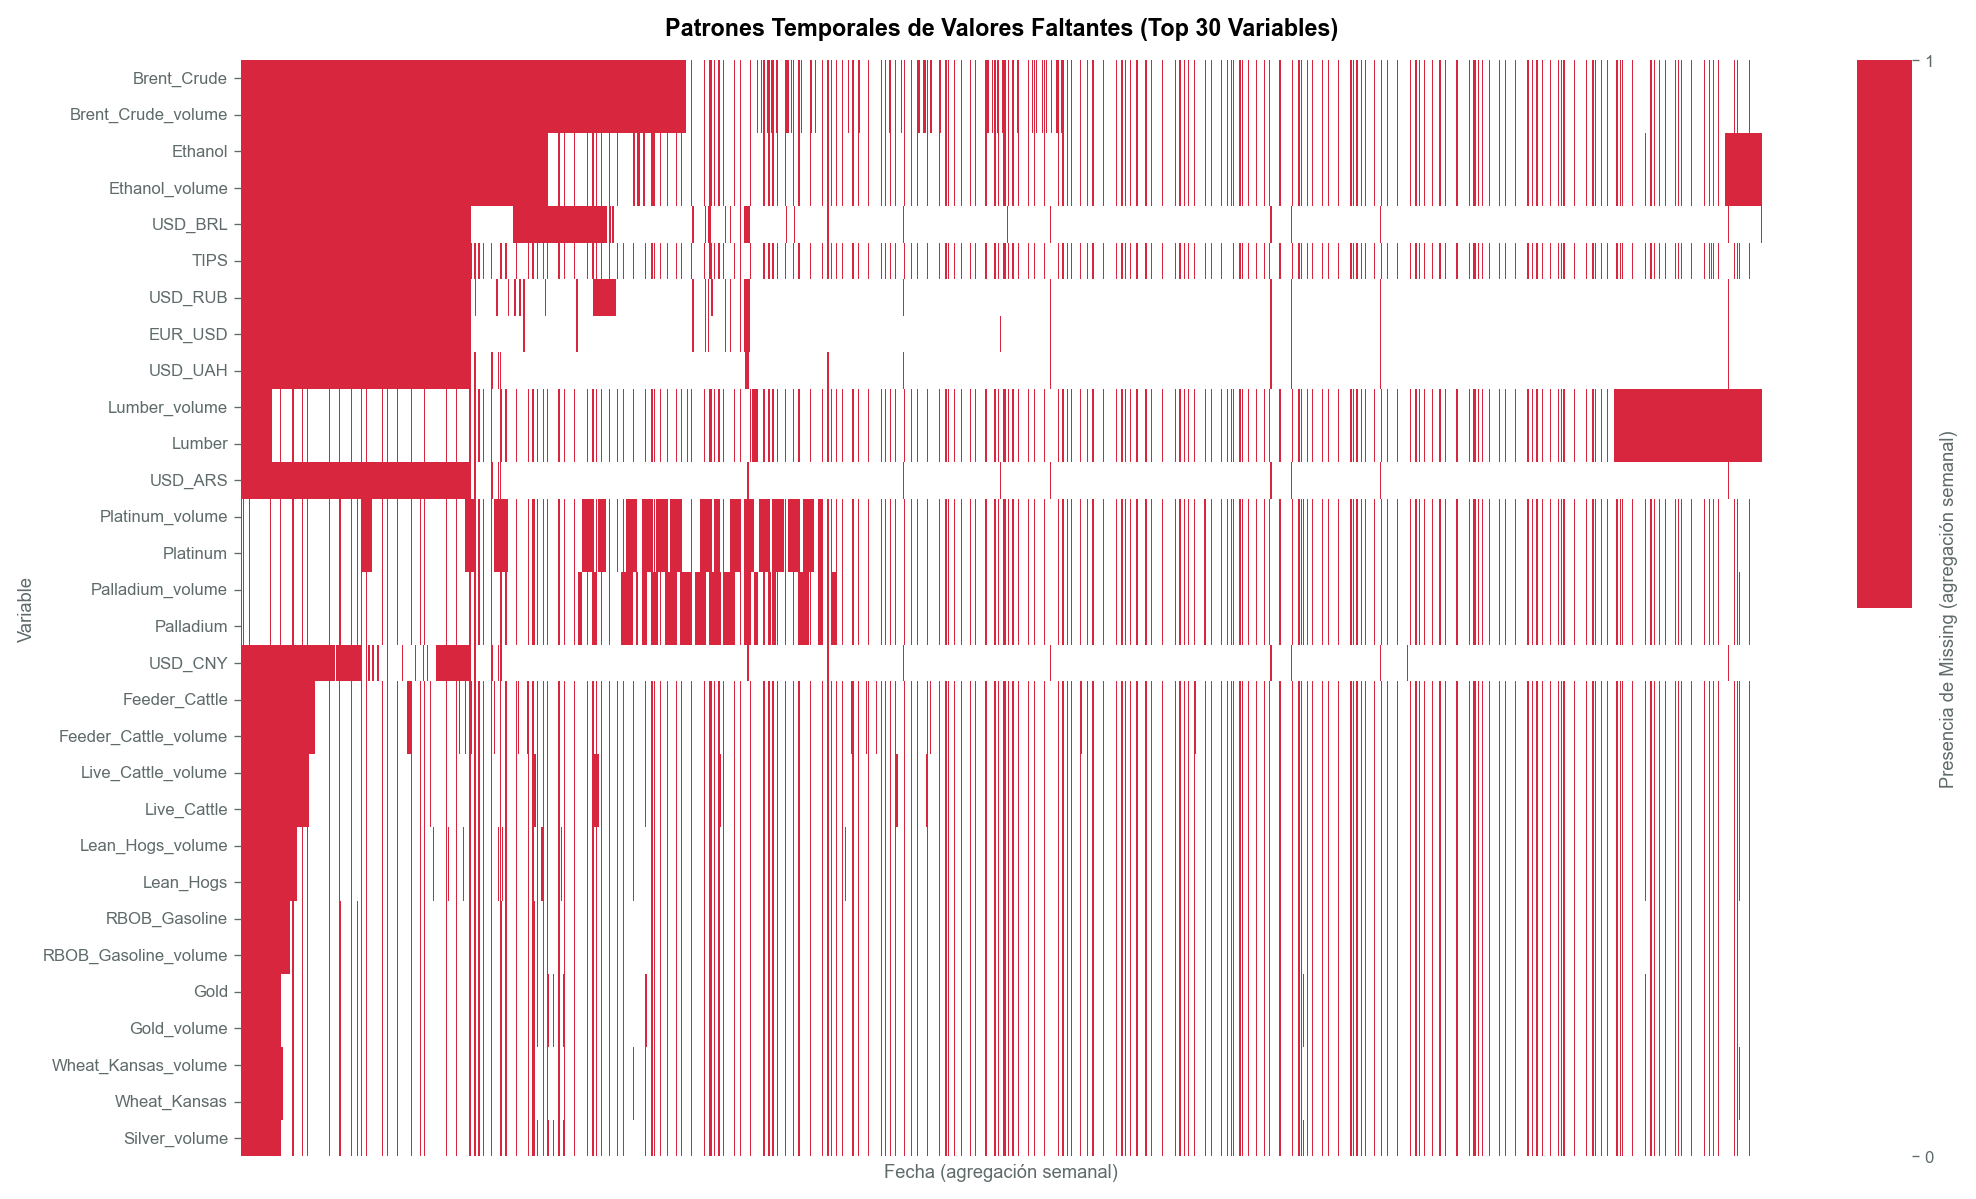

Interpretación del heatmap:
  - Blanco: dato disponible en esa semana
  - Rojo: al menos un día con missing en esa semana
  - Bandas verticales rojas: períodos críticos con alta concentración de missing


In [28]:
# Visualización de patrones temporales de missing values

# Seleccionar top 30 variables con mayor % de missing para visualización
top_missing_vars = missing_vars.head(30)['Variable'].tolist()

if len(top_missing_vars) > 0:
    print(f"\nGenerando heatmap de missing patterns para top {len(top_missing_vars)} variables...\n")
    
    # Crear subset con variables problemáticas
    df_subset = df[['date'] + top_missing_vars].set_index('date').sort_index()
    
    # Crear matriz de missing (True/False)
    missing_matrix = df_subset.isnull()
    
    # Reducir granularidad temporal (semanal) para mejor visualización
    missing_matrix_weekly = missing_matrix.resample('W').max()
    
    # Heatmap con colores institucionales
    fig, ax = plt.subplots(figsize=(18, max(10, len(top_missing_vars) * 0.3)))
    
    sns.heatmap(missing_matrix_weekly.T, 
                cmap=['white', COLORES['rojo']], 
                cbar_kws={'label': 'Presencia de Missing (agregación semanal)', 'ticks': [0, 1]},
                yticklabels=missing_matrix_weekly.columns,
                xticklabels=False,
                ax=ax,
                linewidths=0)
    
    ax.set_title('Patrones Temporales de Valores Faltantes (Top 30 Variables)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fecha (agregación semanal)')
    ax.set_ylabel('Variable')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'exploracion_missing_patterns_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Interpretación del heatmap:")
    print("  - Blanco: dato disponible en esa semana")
    print("  - Rojo: al menos un día con missing en esa semana")
    print("  - Bandas verticales rojas: períodos críticos con alta concentración de missing")
else:
    print("\nNo hay variables con missing values para visualizar")


PREDICTORES IDENTIFICADOS (para predecir commodities agrícolas)
Total de predictores: 68
Muestra: Baltic_Dry_Index, Baltic_Dry_Index_volume, Brent_Crude, Brent_Crude_volume, Copper, Copper_volume, Crude_Oil, Crude_Oil_volume, DXY, ET0_Global_Grain, EUR_USD, Energy_Index, Ethanol, Ethanol_volume, GDD_Global_Grain...


HEATMAP DE MISSING VALUES - PREDICTORES

Predictores con >5% missing (visualizando): 29
Variables: Brent_Crude, Brent_Crude_volume, Ethanol, Ethanol_volume, USD_BRL, TIPS, USD_RUB, EUR_USD, USD_UAH, USD_ARS...


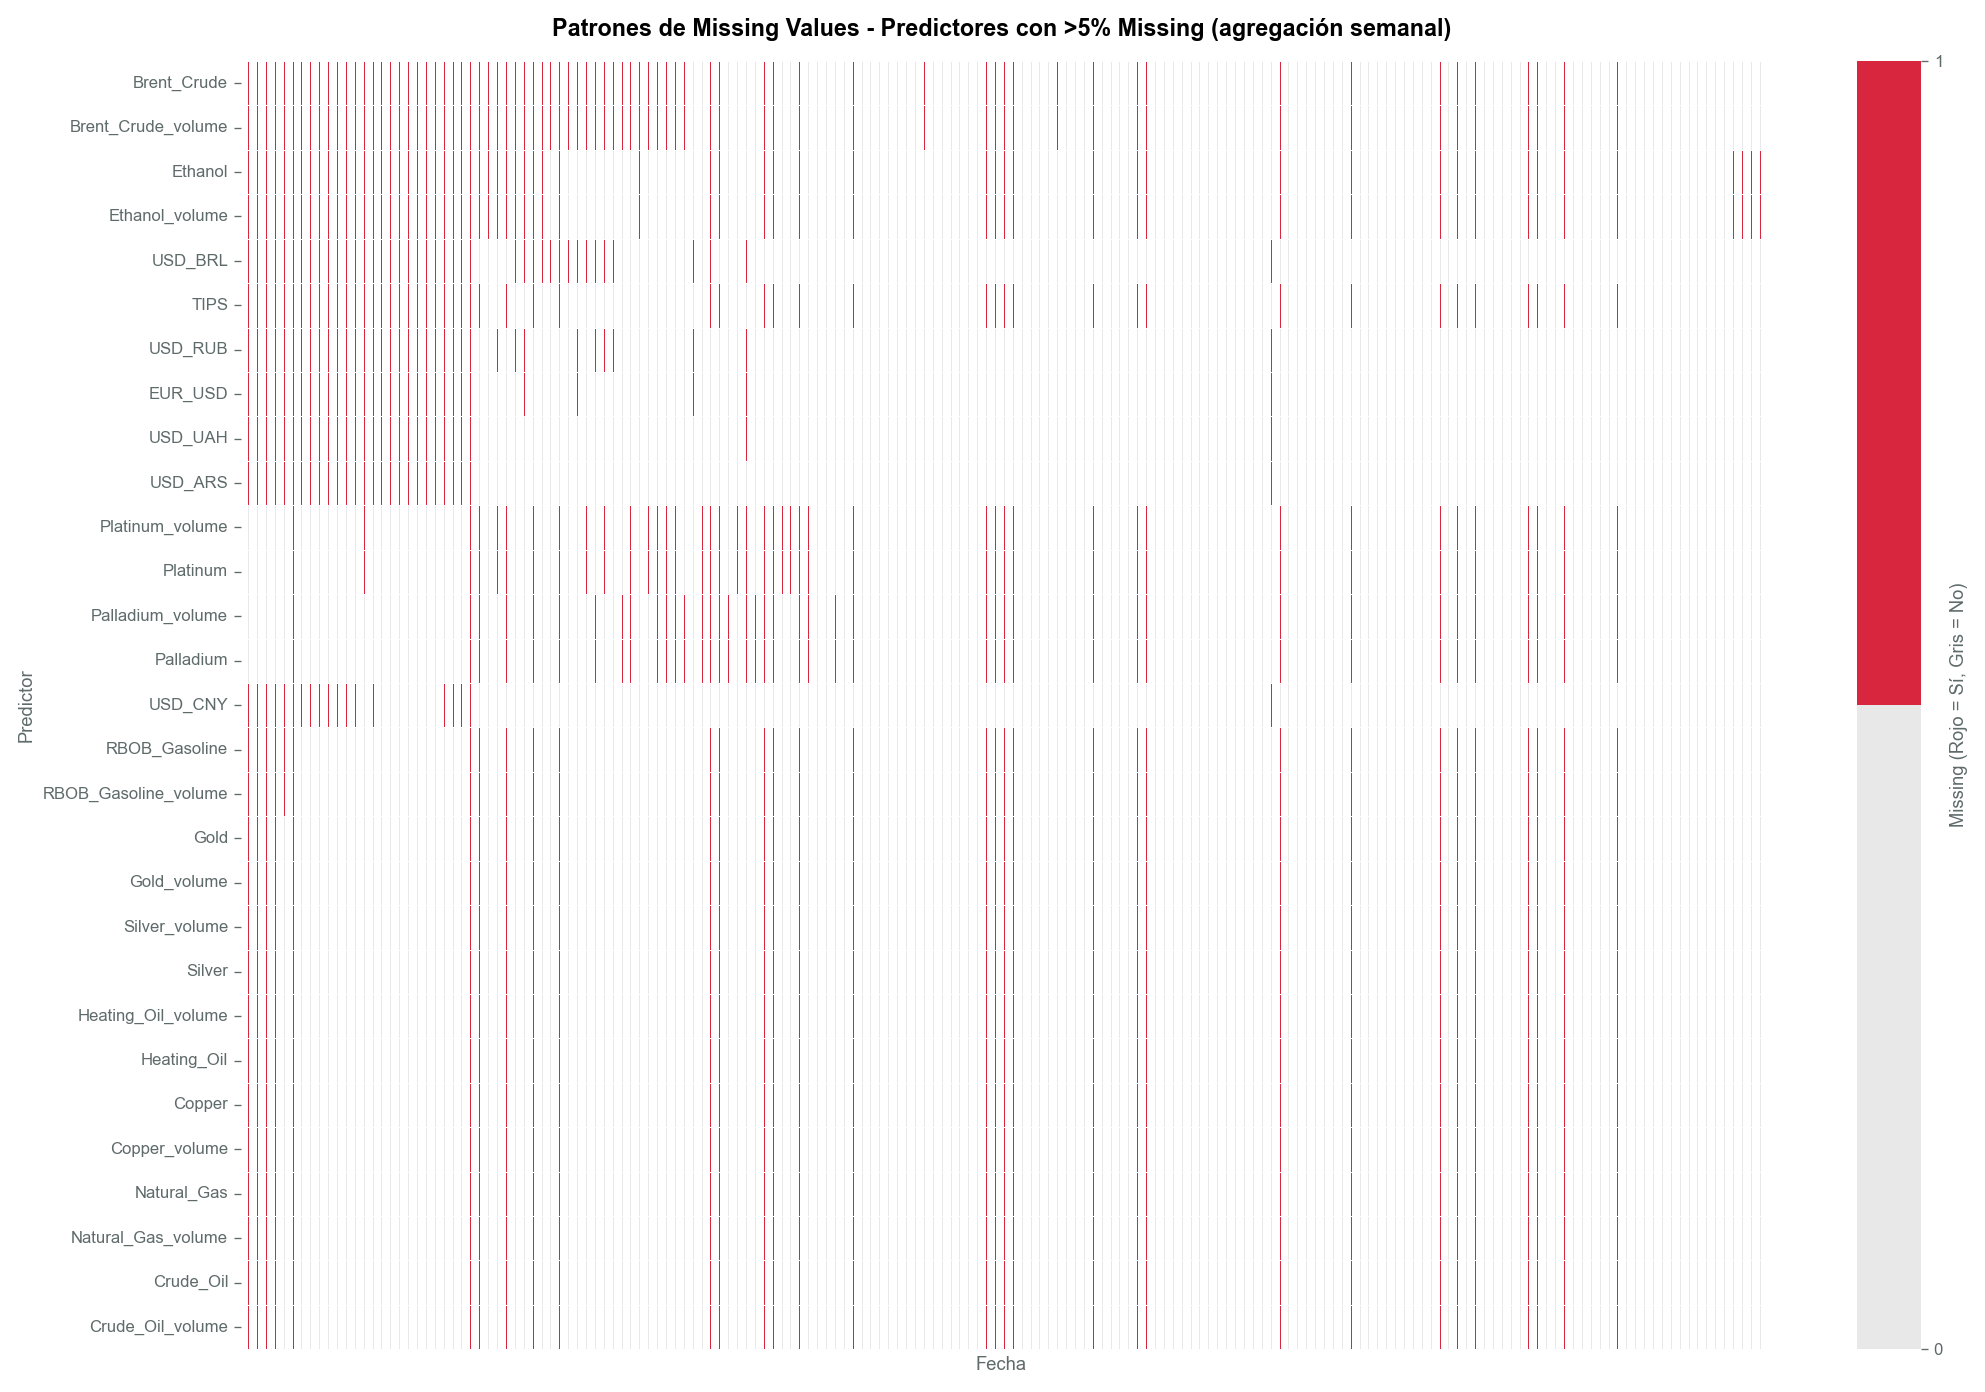


Estadísticas de missing en predictores con >5%:


,Variable,Missing_Count,Missing_Pct,Non_Null
2,Brent_Crude,2181,32.40,4550
29,Brent_Crude_volume,2181,32.40,4550
9,Ethanol,1716,25.49,5015
36,Ethanol_volume,1716,25.49,5015
64,USD_BRL,1456,21.63,5275
60,TIPS,1213,18.02,5518
66,USD_RUB,1146,17.03,5585
56,EUR_USD,1037,15.41,5694
67,USD_UAH,1023,15.20,5708
63,USD_ARS,949,14.10,5782



RESUMEN GENERAL:
  Total predictores: 68
  Predictores con missing >5%: 29
  Missing promedio en todos predictores: 6.51%


In [42]:
# Heatmap específico para PREDICTORES (excluye commodities agrícolas)

print(f"\nPREDICTORES IDENTIFICADOS (para predecir commodities agrícolas)")
print("="*70)
print(f"Total de predictores: {len(predictor_cols)}")
print(f"Muestra: {', '.join(sorted(predictor_cols)[:15])}...")

# Filtrar predictores con missing values SIGNIFICATIVO (>5% para visualización útil)
missing_pred = missing_analysis[missing_analysis['Variable'].isin(predictor_cols)]

if len(missing_pred) > 0:
    print(f"\n\nHEATMAP DE MISSING VALUES - PREDICTORES")
    print("="*70)
    
    # FILTRAR solo predictores con >5% missing para visualización clara
    missing_pred_significativo = missing_pred[missing_pred['Missing_Pct'] > 5.0]
    
    if len(missing_pred_significativo) > 0:
        pred_with_missing = missing_pred_significativo['Variable'].tolist()
        print(f"\nPredictores con >5% missing (visualizando): {len(pred_with_missing)}")
        print(f"Variables: {', '.join(pred_with_missing[:10])}...")
        
        df_pred_subset = df[['date'] + pred_with_missing].set_index('date').sort_index()
        
        # Matriz de missing
        missing_matrix_pred = df_pred_subset.isnull()
        missing_matrix_pred_weekly = missing_matrix_pred.resample('W').max()
        
        # Heatmap con escala de colores más dramática
        fig, ax = plt.subplots(figsize=(18, max(8, len(pred_with_missing) * 0.4)))
        
        # Usar colormap secuencial para mejor contraste
        from matplotlib.colors import ListedColormap
        cmap_missing = ListedColormap(['#E8E8E8', COLORES['rojo']])  # Gris muy claro vs rojo intenso
        
        sns.heatmap(missing_matrix_pred_weekly.T, 
                    cmap=cmap_missing, 
                    cbar_kws={'label': 'Missing (Rojo = Sí, Gris = No)', 'ticks': [0, 1]},
                    yticklabels=missing_matrix_pred_weekly.columns,
                    xticklabels=False,
                    ax=ax,
                    linewidths=0.5,
                    linecolor='white')
        
        ax.set_title('Patrones de Missing Values - Predictores con >5% Missing (agregación semanal)', 
                     fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Fecha')
        ax.set_ylabel('Predictor')
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'exploracion_missing_predictores.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nEstadísticas de missing en predictores con >5%:")
        display(missing_pred_significativo.sort_values('Missing_Pct', ascending=False))
    else:
        print("\nNo hay predictores con >5% missing - completitud excelente")
    
    print(f"\nRESUMEN GENERAL:")
    print(f"  Total predictores: {len(missing_pred)}")
    print(f"  Predictores con missing >5%: {len(missing_pred_significativo) if len(missing_pred_significativo) > 0 else 0}")
    print(f"  Missing promedio en todos predictores: {missing_pred['Missing_Pct'].mean():.2f}%")
else:
    print("\n\nNo hay missing values en predictores")

In [30]:
# Heatmap específico para COMMODITIES AGRÍCOLAS (variables objetivo)

agri_close_cols = [col for col in agri_cols if col.endswith('_close')]
missing_agri = missing_analysis[missing_analysis['Variable'].isin(agri_close_cols)]

if len(missing_agri) > 0:
    print(f"\n\nHEATMAP DE MISSING VALUES - COMMODITIES AGRÍCOLAS (Precios de Cierre)")
    print("="*70)
    
    # Subset solo commodities agrícolas con missing
    agri_with_missing = missing_agri['Variable'].tolist()
    df_agri_subset = df[['date'] + agri_with_missing].set_index('date').sort_index()
    
    # Matriz de missing
    missing_matrix_agri = df_agri_subset.isnull()
    missing_matrix_agri_weekly = missing_matrix_agri.resample('W').max()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(18, max(8, len(agri_with_missing) * 0.4)))
    
    sns.heatmap(missing_matrix_agri_weekly.T, 
                cmap=['white', COLORES['verde_eco']], 
                cbar_kws={'label': 'Missing', 'ticks': [0, 1]},
                yticklabels=[c.replace('_close', '') for c in missing_matrix_agri_weekly.columns],
                xticklabels=False,
                ax=ax,
                linewidths=0.1,
                linecolor='lightgray')
    
    ax.set_title('Patrones de Missing Values - Commodities Agrícolas (agregación semanal)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Commodity Agrícola')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'exploracion_missing_agricolas.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nTotal commodities agrícolas con missing: {len(agri_with_missing)}")
    print(f"Missing promedio: {missing_agri['Missing_Pct'].mean():.2f}%")
else:
    print("\n\nNo hay missing values en precios de cierre de commodities agrícolas")



No hay missing values en precios de cierre de commodities agrícolas


## 4. Visualización de Series Temporales

**Objetivo:** Identificar visualmente características de las series de precios:
- **Tendencias**: Movimientos de largo plazo (alcistas, bajistas, estacionarias)
- **Estacionalidad**: Patrones recurrentes intra-año
- **Volatilidad**: Variabilidad de los precios en el tiempo
- **Outliers**: Valores extremos que podrían requerir tratamiento
- **Cambios estructurales**: Quiebres de tendencia asociados a eventos (crisis, pandemias, guerras)

**Selección de commodities representativos:**
- Energía: Crude Oil, Natural Gas
- Metales preciosos: Gold, Silver
- Metales industriales: Copper
- Agrícolas: Corn, Soybeans

Estas series cubren diferentes sectores y permiten evaluar comportamientos heterogéneos.

VISUALIZACIÓN DE COMMODITIES AGRÍCOLAS (Variables Objetivo)
Visualizando 6 commodities agrícolas



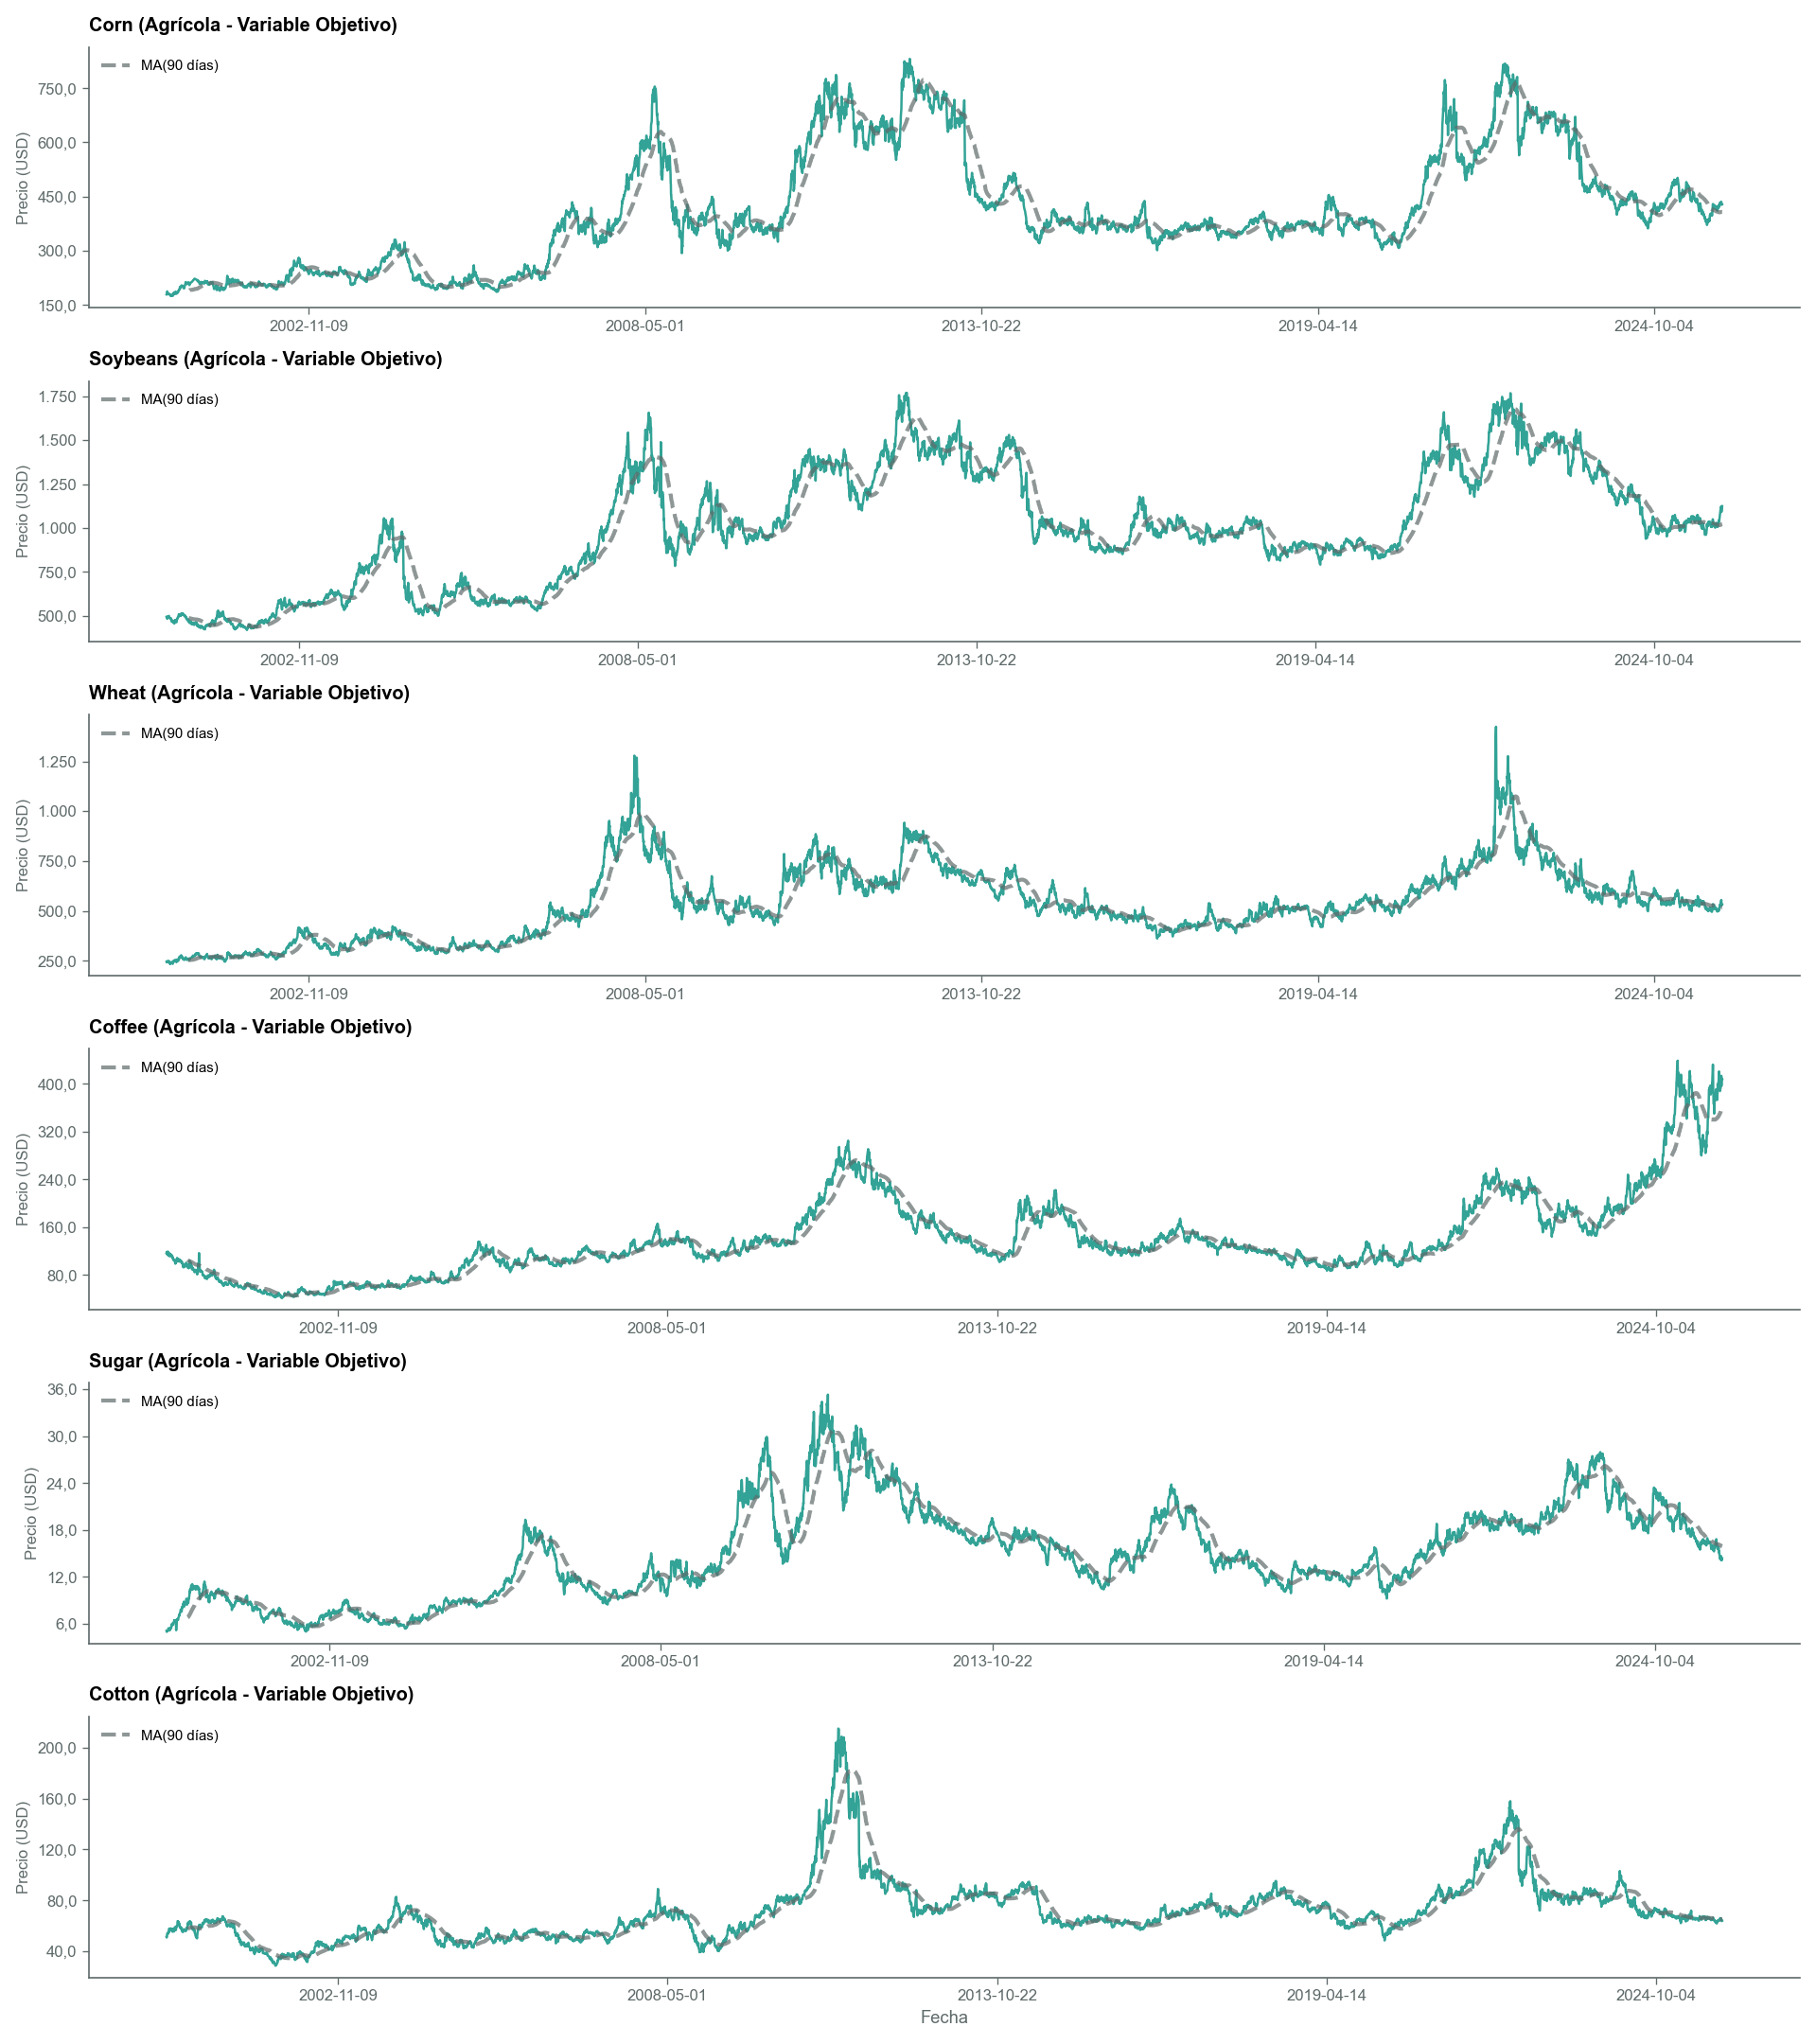


✓ Gráfico guardado en C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\reports\figures\exploracion_series_temporales_agricolas.png


In [31]:
# Visualización de COMMODITIES AGRÍCOLAS (variables objetivo)

# Seleccionar commodities agrícolas representativos
agri_to_viz = ['Corn', 'Soybeans', 'Wheat', 'Coffee', 'Sugar', 'Cotton']

# Verificar disponibilidad en el dataset
agri_available = [col for col in agri_to_viz if col in df.columns]

print(f"VISUALIZACIÓN DE COMMODITIES AGRÍCOLAS (Variables Objetivo)")
print("="*70)
print(f"Visualizando {len(agri_available)} commodities agrícolas\n")

if len(agri_available) > 0:
    fig, axes = plt.subplots(len(agri_available), 1, figsize=(16, 3*len(agri_available)))
    
    if len(agri_available) == 1:
        axes = [axes]
    
    for i, commodity in enumerate(agri_available):
        # Extraer serie temporal
        serie = df[['date', commodity]].dropna().sort_values('date')
        
        # Graficar
        axes[i].plot(serie['date'], serie[commodity], 
                    linewidth=1.5, 
                    color=COLORES['verde_eco'],
                    alpha=0.9)
        
        # Añadir media móvil de 90 días
        if len(serie) > 90:
            ma_90 = serie[commodity].rolling(window=90).mean()
            axes[i].plot(serie['date'], ma_90, 
                        linewidth=2.5, 
                        color=COLORES['gris_oscuro'],
                        linestyle='--',
                        alpha=0.7,
                        label='MA(90 días)')
        
        # Formato
        axes[i].set_title(f'{commodity} (Agrícola - Variable Objetivo)', 
                         fontsize=12, fontweight='bold', loc='left', pad=10)
        axes[i].set_ylabel('Precio (USD)', fontsize=10)
        axes[i].legend(loc='upper left', fontsize=9)
        axes[i].grid(False)
        formatear_ejes(axes[i], y_as='numero')
    
    axes[-1].set_xlabel('Fecha', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'exploracion_series_temporales_agricolas.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Gráfico guardado en {FIGURES_DIR / 'exploracion_series_temporales_agricolas.png'}")
else:
    print("No se encontraron commodities agrícolas para visualizar")

### 4.2 Predictores Macroeconómicos

Visualización de índices y tasas que podrían explicar movimientos en commodities:
- **VIX**: Volatilidad implícita del S&P 500 (fear index)
- **DXY**: Índice del dólar estadounidense (impacta precios en USD)
- **SP500**: S&P 500 (sentimiento de mercado)
- **Treasury yields**: Tasas de bonos del tesoro (expectativas de inflación)

VISUALIZACIÓN DE PREDICTORES (muestra representativa)
Visualizando 12 predictores en 6 categorías
Predictores seleccionados: ['Crude_Oil', 'Brent_Crude', 'Gold', 'Silver', 'DXY', 'VIX', 'Treasury_10Y', 'Treasury_2Y', 'psd_world_Production', 'psd_world_Ending_Stocks', 'RH_Global_Grain', 'SolarRad_Global_Grain']



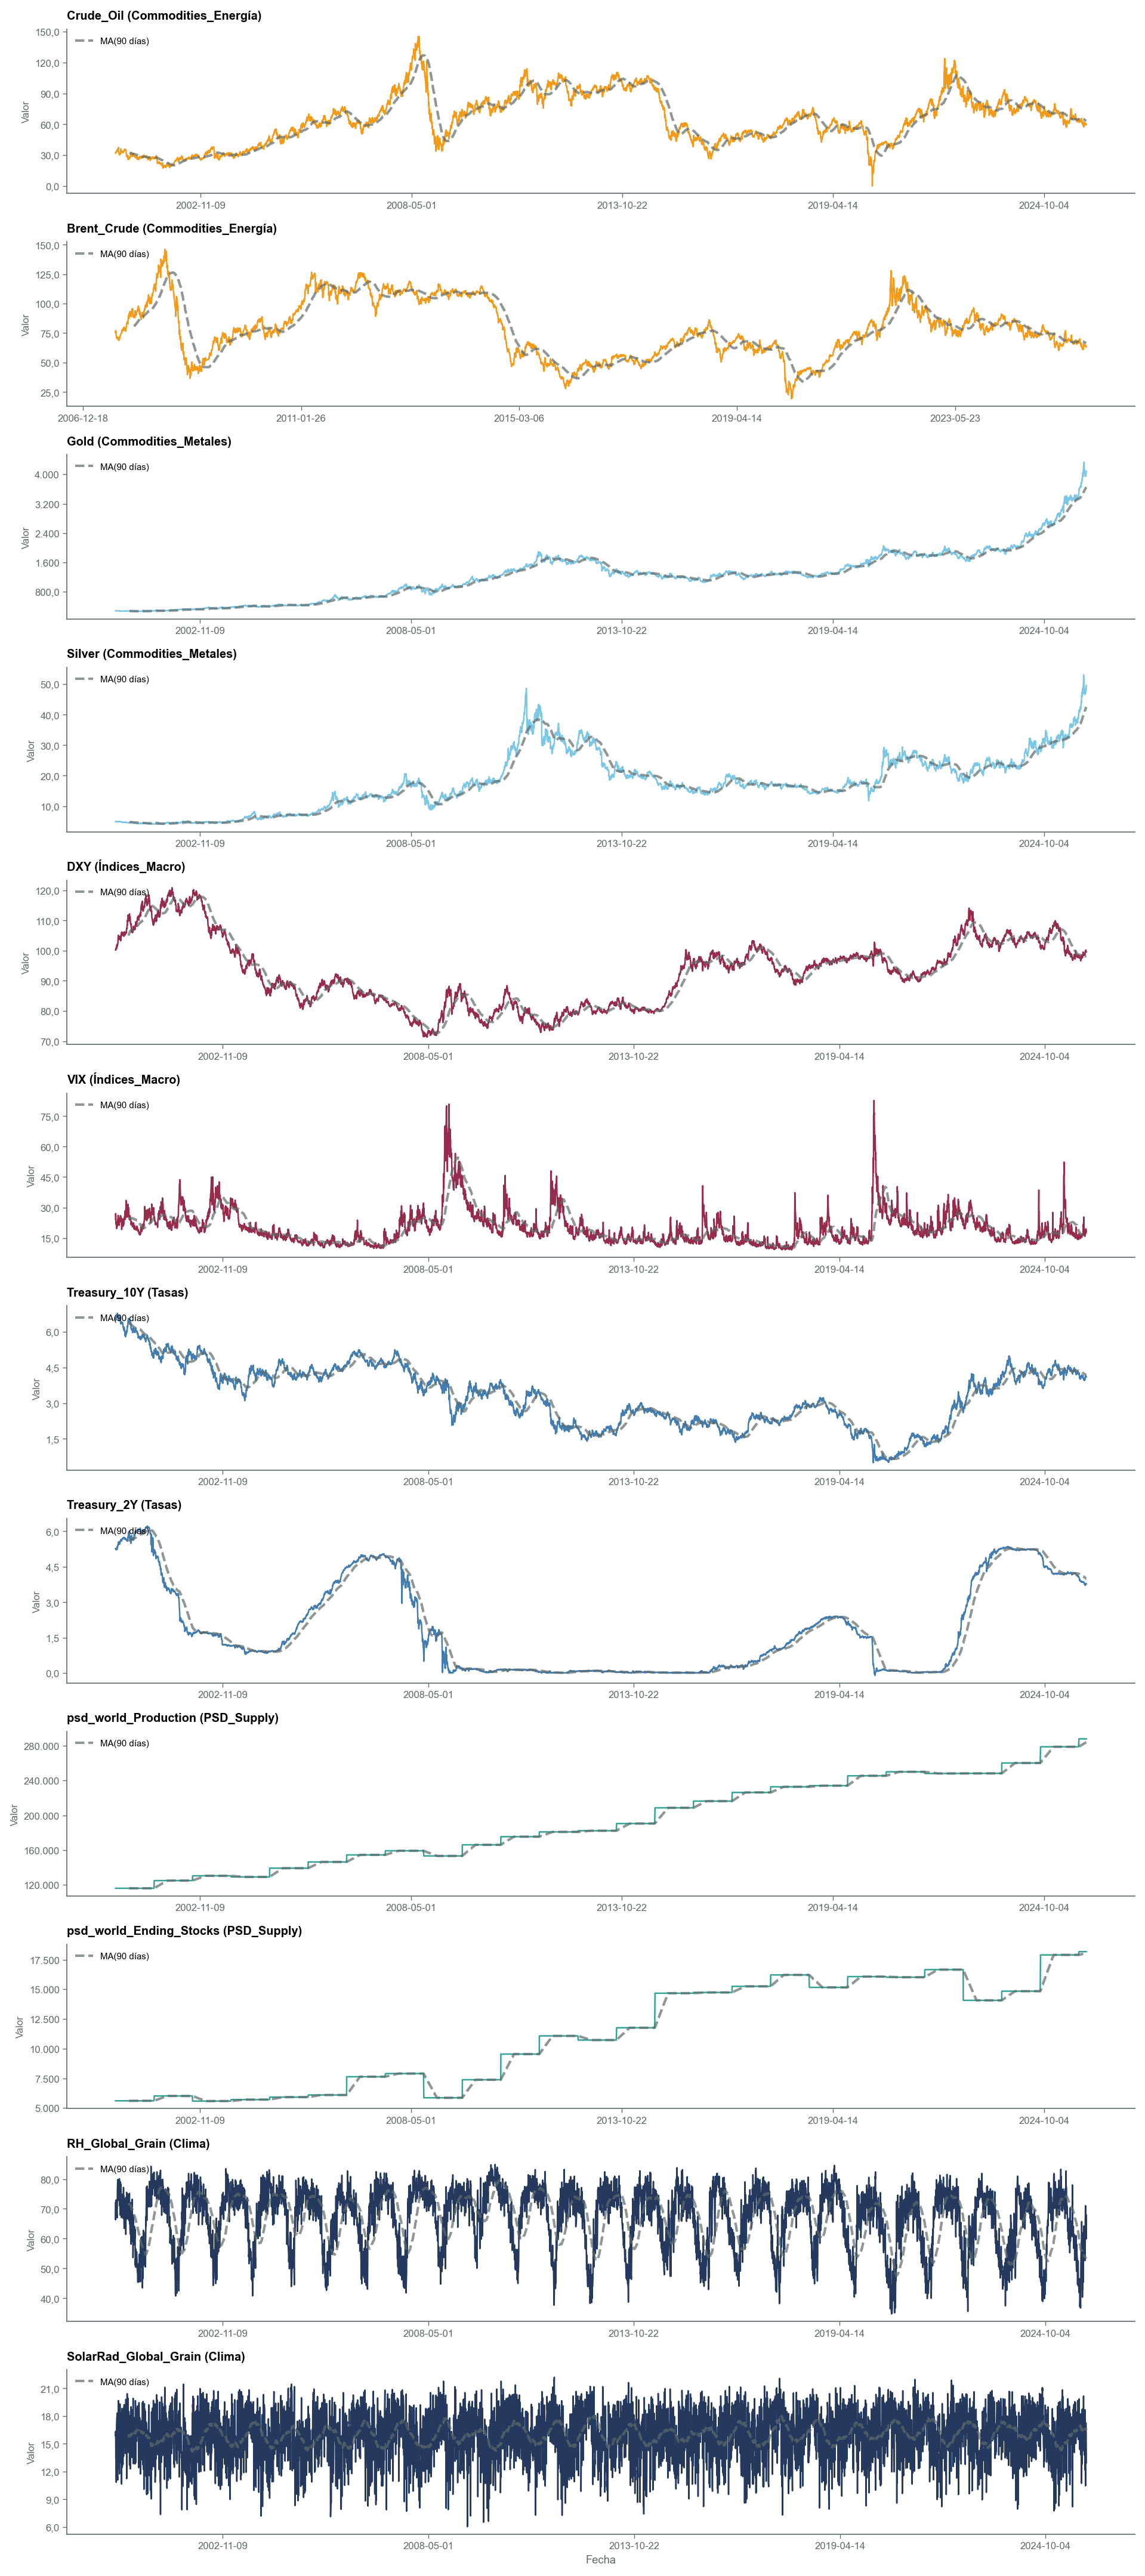


✓ Gráfico guardado en C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\reports\figures\exploracion_series_temporales_predictores.png


In [39]:
# Visualización de PREDICTORES (selección representativa por categoría)

# Seleccionar predictores representativos de cada categoría
predictores_viz = {
    'Commodities_Energía': ['Crude_Oil', 'Brent_Crude', 'Natural_Gas'],
    'Commodities_Metales': ['Gold', 'Silver', 'Copper'],
    'Índices_Macro': ['DXY', 'VIX', 'SP500'],
    'Tasas': ['Treasury_10Y', 'Treasury_2Y'],
    'PSD_Supply': ['psd_world_Production', 'psd_world_Ending_Stocks'],
    'Clima': ['RH_Global_Grain', 'SolarRad_Global_Grain']
}

# Verificar disponibilidad y aplanar (buscar en df.columns directamente)
predictores_disponibles_viz = []
for categoria, preds in predictores_viz.items():
    count = 0
    for pred in preds:
        if pred in df.columns and count < 2:  # Max 2 por categoría
            predictores_disponibles_viz.append((categoria, pred))
            count += 1
        elif count < 2:  # Debug: mostrar cuáles no se encuentran
            # Buscar variantes con sufijos
            for col in df.columns:
                if pred in col and col in predictor_cols and count < 2:
                    predictores_disponibles_viz.append((categoria, col))
                    count += 1
                    break

print(f"VISUALIZACIÓN DE PREDICTORES (muestra representativa)")
print("="*70)
print(f"Visualizando {len(predictores_disponibles_viz)} predictores en {len(predictores_viz)} categorías")
if len(predictores_disponibles_viz) > 0:
    print(f"Predictores seleccionados: {[p[1] for p in predictores_disponibles_viz]}\n")
else:
    print("\n")

if len(predictores_disponibles_viz) > 0:
    fig, axes = plt.subplots(len(predictores_disponibles_viz), 1, 
                            figsize=(16, 3*len(predictores_disponibles_viz)))
    
    if len(predictores_disponibles_viz) == 1:
        axes = [axes]
    
    colores_cat = {
        'Commodities_Energía': COLORES['naranja'],
        'Commodities_Metales': COLORES['celeste'],
        'Índices_Macro': COLORES['bordo'],
        'Tasas': COLORES['azul_medio'],
        'PSD_Supply': COLORES['verde_eco'],
        'Clima': COLORES['azul_uba']
    }
    
    for i, (categoria, predictor) in enumerate(predictores_disponibles_viz):
        # Extraer serie
        serie = df[['date', predictor]].dropna().sort_values('date')
        
        # Graficar
        axes[i].plot(serie['date'], serie[predictor], 
                    linewidth=1.5, 
                    color=colores_cat.get(categoria, COLORES['gris_oscuro']),
                    alpha=0.9)
        
        # Media móvil 90 días
        if len(serie) > 90:
            ma_90 = serie[predictor].rolling(window=90).mean()
            axes[i].plot(serie['date'], ma_90, 
                        linewidth=2.5, 
                        color=COLORES['gris_oscuro'],
                        linestyle='--',
                        alpha=0.7,
                        label='MA(90 días)')
        
        # Formato
        axes[i].set_title(f'{predictor} ({categoria})', 
                         fontsize=12, fontweight='bold', loc='left', pad=10)
        axes[i].set_ylabel('Valor', fontsize=10)
        axes[i].legend(loc='upper left', fontsize=9)
        formatear_ejes(axes[i], y_as='numero')
        axes[i].grid(False)
    
    axes[-1].set_xlabel('Fecha', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'exploracion_series_temporales_predictores.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Gráfico guardado en {FIGURES_DIR / 'exploracion_series_temporales_predictores.png'}")
else:
    print("No se encontraron predictores para visualizar")

## 5. Estadísticas Descriptivas

**Objetivo:** Calcular medidas de tendencia central y dispersión para caracterizar la distribución de cada variable.

**Medidas calculadas:**
- **count**: Número de observaciones válidas (no-null)
- **mean/std**: Media y desviación estándar (sensibles a outliers)
- **min/max**: Rango de valores observados
- **25%/50%/75%**: Cuartiles (percentiles 25, 50, 75)
- **CV (Coeficiente de Variación)**: std/mean, mide variabilidad relativa (útil para comparar series con diferentes escalas)

**Interpretación del CV:**
- CV < 0.5: Baja variabilidad
- 0.5 < CV < 1.0: Variabilidad moderada
- CV > 1.0: Alta variabilidad (típico en commodities volátiles como energía)

In [35]:
# Estadísticas para COMMODITIES AGRÍCOLAS (variables objetivo)

# Seleccionar solo columnas de precios (sin _volume)
agri_price_cols = [col for col in agri_cols if '_volume' not in col]

print("ESTADÍSTICAS DESCRIPTIVAS - COMMODITIES AGRÍCOLAS (Variables Objetivo)")
print("="*70)

if len(agri_price_cols) > 0:
    stats_agri = df[agri_price_cols].describe().T
    stats_agri.columns = ['Count', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max']
    stats_agri['CV'] = (stats_agri['Std'] / stats_agri['Mean']).round(3)
    stats_agri['Range'] = (stats_agri['Max'] - stats_agri['Min']).round(2)

    # Nombres ya están limpios (sin sufijos _close)

    # Ordenar por CV
    stats_agri_sorted = stats_agri.sort_values('CV', ascending=False)

    display(stats_agri_sorted)

    print(f"\nResumen de variabilidad:")
    print(f"  CV promedio: {stats_agri['CV'].mean():.3f}")
    print(f"  Commodity más volátil: {stats_agri['CV'].idxmax()} (CV={stats_agri['CV'].max():.3f})")
    print(f"  Commodity menos volátil: {stats_agri['CV'].idxmin()} (CV={stats_agri['CV'].min():.3f})")
else:
    print("No se encontraron commodities agrícolas")

ESTADÍSTICAS DESCRIPTIVAS - COMMODITIES AGRÍCOLAS (Variables Objetivo)


,Count,Mean,Std,Min,25%,Median,75%,Max,CV,Range
Cocoa,"6,485.00","2,699.74","1,786.71",674.00,"1,799.00","2,397.00","2,904.00","12,565.00",0.66,"11,891.00"
Lumber,"5,723.00",355.76,192.65,138.10,251.00,309.30,373.70,"1,686.00",0.54,"1,547.90"
Coffee,"6,483.00",141.44,67.95,41.50,102.60,125.15,171.10,438.90,0.48,397.40
Oat,"6,338.00",284.70,115.85,96.50,199.00,274.25,355.25,807.00,0.41,710.50
Sugar,"6,446.00",15.06,5.90,4.96,10.47,14.62,18.97,35.31,0.39,30.35
Soybean_Oil,"6,376.00",37.68,14.67,14.38,27.60,33.88,49.04,90.60,0.39,76.22
Corn,"6,335.00",411.74,157.52,174.75,317.50,377.75,495.00,831.25,0.38,656.50
Feeder_Cattle,"6,160.00",145.70,54.64,73.50,107.19,137.70,159.32,380.17,0.38,306.67
Wheat_Kansas,"6,324.00",564.86,194.40,271.25,421.25,517.25,698.31,"1,367.75",0.34,"1,096.50"
Cotton,"6,485.00",71.58,24.22,28.52,56.93,67.51,81.76,215.15,0.34,186.63



Resumen de variabilidad:
  CV promedio: 0.388
  Commodity más volátil: Cocoa (CV=0.662)
  Commodity menos volátil: Lean_Hogs (CV=0.234)


In [36]:
# Estadísticas para PREDICTORES (muestra de variables numéricas)

# Seleccionar predictores numéricos (excluir variables PSD con muchos NaN)
predictores_numericos = [col for col in predictor_cols 
                         if df[col].dtype in ['float64', 'int64'] 
                         and df[col].count() > len(df) * 0.5]  # >50% datos válidos

print("\nESTADÍSTICAS DESCRIPTIVAS - PREDICTORES (muestra con >50% completitud)")
print("="*70)

if len(predictores_numericos) > 0:
    stats_pred = df[predictores_numericos].describe().T
    stats_pred.columns = ['Count', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max']
    stats_pred['CV'] = (stats_pred['Std'] / stats_pred['Mean']).round(3)
    stats_pred['Range'] = (stats_pred['Max'] - stats_pred['Min']).round(2)
    stats_pred['Completitud_%'] = (stats_pred['Count'] / len(df) * 100).round(2)
    
    # Ordenar por completitud descendente
    stats_pred_sorted = stats_pred.sort_values('Completitud_%', ascending=False)
    
    display(stats_pred_sorted.head(30))  # Mostrar top 30
    
    print(f"\nResumen de variabilidad:")
    print(f"  CV promedio: {stats_pred['CV'].mean():.3f}")
    print(f"  Total predictores con >50% datos: {len(predictores_numericos)}")
else:
    print("\nNo hay predictores numéricos con suficientes datos")


ESTADÍSTICAS DESCRIPTIVAS - PREDICTORES (muestra con >50% completitud)


,Count,Mean,Std,Min,25%,Median,75%,Max,CV,Range,Completitud_%
ONI,"6,731.00",-0.06,0.81,-1.66,-0.62,-0.16,0.43,2.64,-13.85,4.30,100.00
Heat_Stress_Days,"6,731.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,100.00
Precip_Deficit,"6,731.00",-5.86,55.77,-94.83,-52.93,-16.83,34.67,222.30,-9.52,317.14,100.00
Temp_Global_Grain,"6,730.00",17.61,3.16,7.66,15.23,17.73,20.03,26.36,0.18,18.70,99.99
Precip_Global_Grain,"6,730.00",3.14,3.94,0.00,0.33,1.72,4.47,40.34,1.25,40.34,99.99
RH_Global_Grain,"6,730.00",66.91,10.22,34.74,59.92,70.06,74.70,84.91,0.15,50.17,99.99
WindSpeed_Global_Grain,"6,730.00",1.33,0.40,0.44,1.04,1.27,1.57,3.32,0.30,2.88,99.99
GDD_Global_Grain,"6,730.00",7.61,3.15,0.00,5.23,7.73,10.03,16.36,0.41,16.36,99.99
SolarRad_Global_Grain,"6,725.00",16.01,2.65,6.02,14.22,16.23,18.07,22.20,0.17,16.18,99.91
ET0_Global_Grain,"6,725.00",2.60,0.61,0.47,2.19,2.62,3.04,5.06,0.23,4.60,99.91



Resumen de variabilidad:
  CV promedio: 0.417
  Total predictores con >50% datos: 68


DISTRIBUCIONES DE PRECIOS - COMMODITIES AGRÍCOLAS



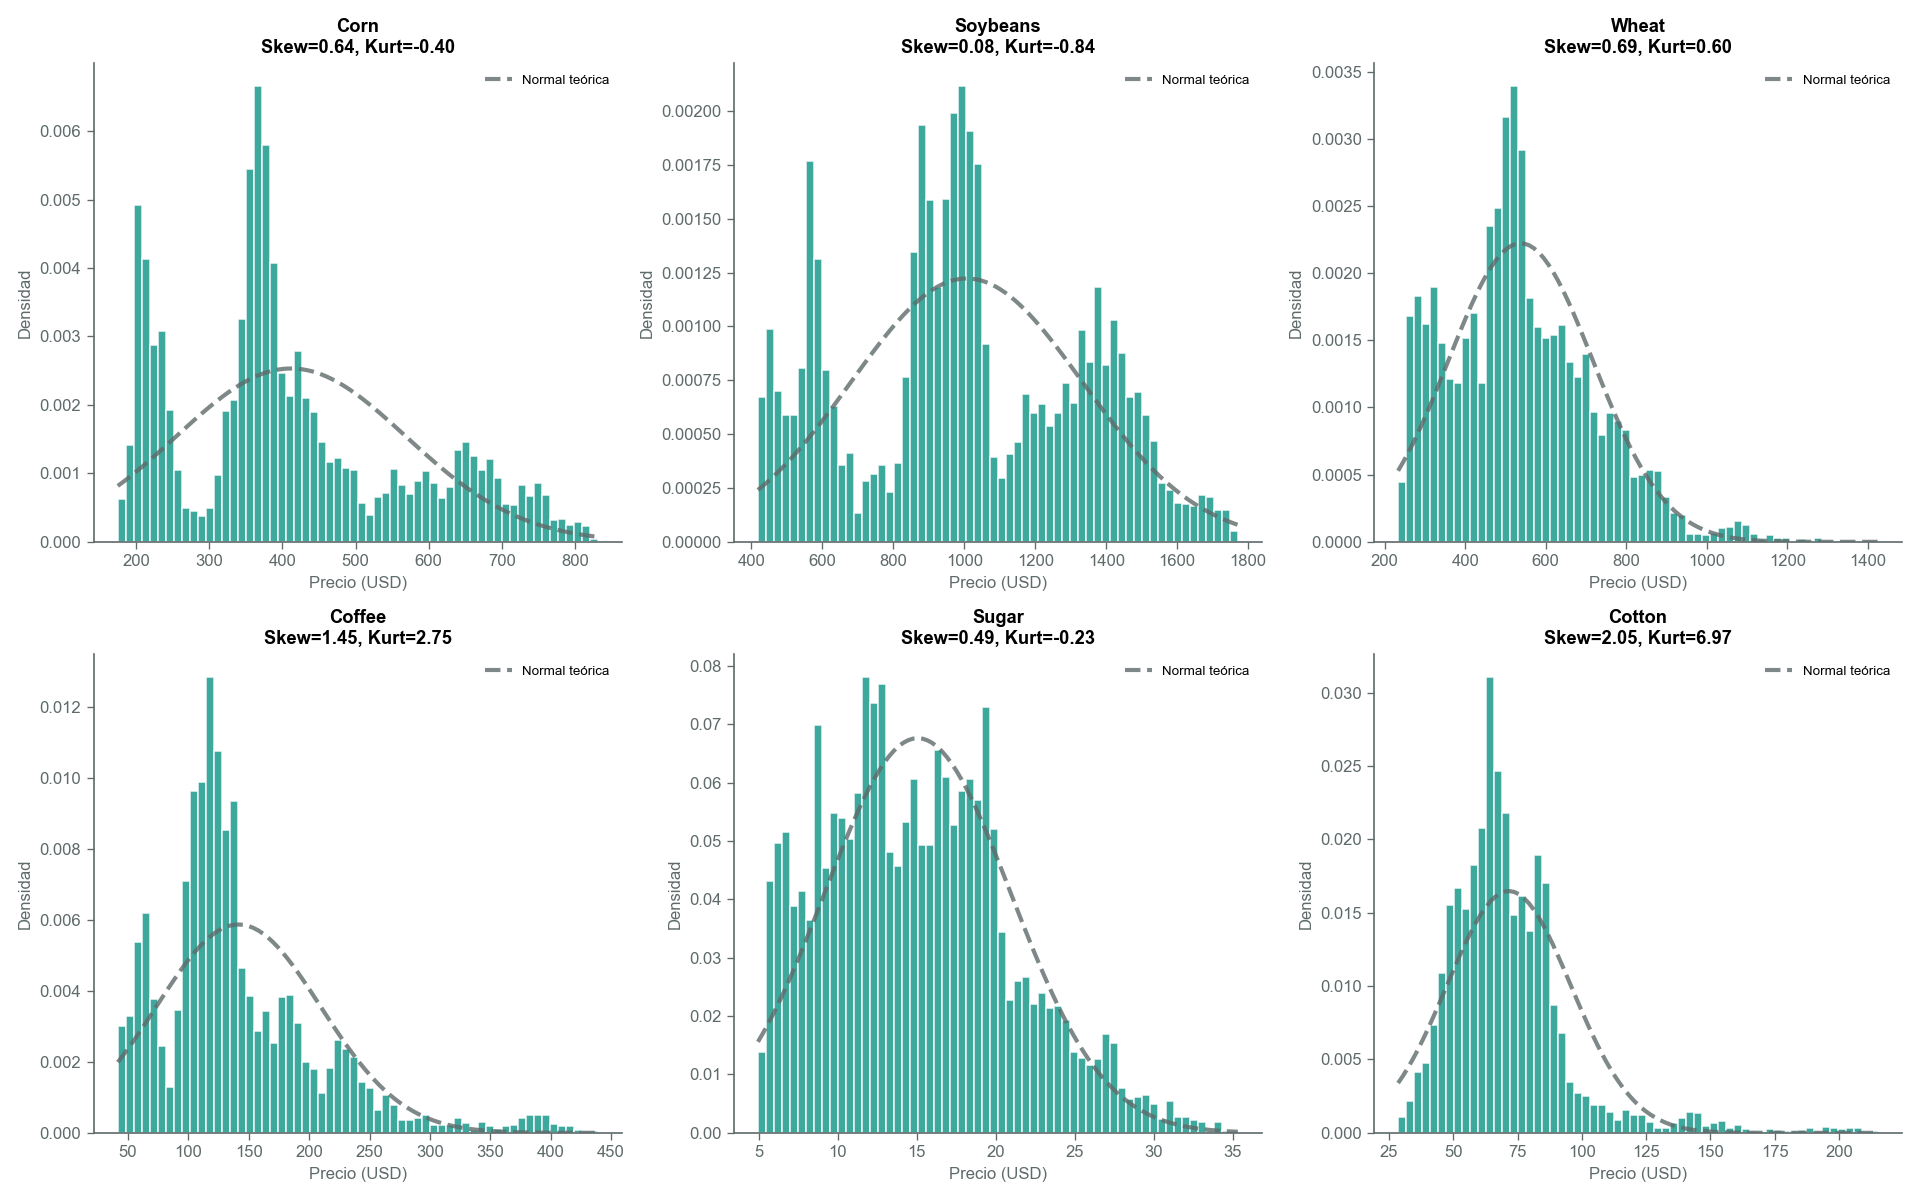

Interpretación:
  - Skewness > 0: Asimetría derecha (cola larga hacia valores altos)
  - Skewness < 0: Asimetría izquierda (cola larga hacia valores bajos)
  - Kurtosis > 0: Colas más pesadas que distribución normal (leptocúrtica)
  - Kurtosis < 0: Colas más ligeras que distribución normal (platicúrtica)


In [38]:
# Histogramas de COMMODITIES AGRÍCOLAS (variables objetivo)

# Seleccionar 6 commodities agrícolas para histogramas (sin sufijo _close)
agri_for_hist = ['Corn', 'Soybeans', 'Wheat', 'Coffee', 'Sugar', 'Cotton']

# Verificar disponibilidad
agri_for_hist = [c for c in agri_for_hist if c in df.columns]

if len(agri_for_hist) > 0:
    print("DISTRIBUCIONES DE PRECIOS - COMMODITIES AGRÍCOLAS")
    print("="*70 + "\n")
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    from scipy.stats import skew, kurtosis, norm

    for i, commodity in enumerate(agri_for_hist):
        serie = df[commodity].dropna()
        
        # Calcular estadísticos
        skewness = skew(serie)
        kurt = kurtosis(serie, fisher=True)
        
        # Histograma
        axes[i].hist(serie, bins=60, edgecolor='white', alpha=0.85, 
                    color=COLORES['verde_eco'], density=True)
        
        # Overlay distribución normal
        mu, sigma = serie.mean(), serie.std()
        x_range = np.linspace(serie.min(), serie.max(), 100)
        axes[i].plot(x_range, norm.pdf(x_range, mu, sigma), 
                    linewidth=2.5, color=COLORES['gris_oscuro'], 
                    linestyle='--', label='Normal teórica', alpha=0.8)
        
        # Formato
        commodity_name = commodity.replace('_', ' ')
        axes[i].set_title(f'{commodity_name}\nSkew={skewness:.2f}, Kurt={kurt:.2f}', 
                         fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Precio (USD)', fontsize=10)
        axes[i].set_ylabel('Densidad', fontsize=10)
        axes[i].legend(loc='upper right', frameon=False, fontsize=8)
        axes[i].grid(False)

    # Eliminar subplots vacíos si hay menos de 6
    for j in range(len(agri_for_hist), 6):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'exploracion_distribuciones_agricolas.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Interpretación:")
    print("  - Skewness > 0: Asimetría derecha (cola larga hacia valores altos)")
    print("  - Skewness < 0: Asimetría izquierda (cola larga hacia valores bajos)")
    print("  - Kurtosis > 0: Colas más pesadas que distribución normal (leptocúrtica)")
    print("  - Kurtosis < 0: Colas más ligeras que distribución normal (platicúrtica)")
else:
    print("No se encontraron commodities agrícolas para histogramas")

## 7. Conclusiones del Análisis Exploratorio

### 7.1 Estructura del Dataset

**Alcance Temporal:**
- **Período de análisis: 2000-01-01 en adelante** (definido en `config.START_DATE`)
- Enfoque en datos del milenio para relevancia del análisis
- Datos pre-2000 descartados automáticamente
- Aproximadamente ~25 años de datos históricos (~6,500 observaciones diarias)

**Variables Objetivo (Commodities Agrícolas):**
- 15 commodities agrícolas identificados como variables a predecir
- Incluyen granos (Corn, Soybeans, Wheat), softs (Coffee, Sugar, Cocoa, Cotton), ganado (Live Cattle, Lean Hogs)
- Formato OHLCV completo (Open, High, Low, Close, Volume) para cada commodity
- Cobertura temporal generalmente completa (>90% de observaciones) en período 2000+

**Variables Predictoras (64 predictores):**
- **Commodities no-agrícolas** (energía y metales): Crude Oil, Brent, Natural Gas, Gold, Silver, Copper, Platinum, Palladium
- **Índices macroeconómicos**: DXY (dólar), VIX (volatilidad), SP500, Treasury yields, TIPS
- **Divisas**: EUR/USD, USD/ARS, USD/BRL, USD/CNY, USD/RUB, USD/UAH
- **Variables PSD (supply-demand)**: Producción, stocks, exportaciones, importaciones para 5 países (World, Brazil, USA, Argentina, China)
- **Variables climáticas**: Humedad relativa, radiación solar, velocidad del viento para regiones productoras de granos

### 7.2 Calidad de Datos

**Cobertura temporal:**
- Dataset consolidado con período completo desde fechas mínimas de cada fuente
- Commodities agrícolas (objetivo) tienen cobertura casi completa
- Predictores PSD tienen missing estructural (datos trimestrales/anuales, no diarios)
- Predictores climáticos pueden tener gaps por limitaciones de satélites/estaciones

**Valores faltantes:**
- Variables PSD con >30% missing son esperadas (no reportadas diariamente)
- Commodities energía/metales generalmente completos (trading diario)
- Missing en divisas emerging markets (ARS, RUB, UAH) relacionado con crisis cambiarias

**Recomendaciones para limpieza:**
1. **Commodities agrícolas**: Forward-fill para gaps de fines de semana/feriados (<10% missing)
2. **Predictores PSD**: LOCF (Last Observation Carried Forward) - datos válidos hasta próxima actualización
3. **Predictores climáticos**: Interpolación lineal para gaps cortos (<7 días)
4. **Variables con >50% missing**: Evaluar exclusión o imputación sofisticada (KNN, MICE)

### 7.3 Características de las Series

**Commodities Agrícolas (objetivo):**
- **Estacionalidad marcada** relacionada con ciclos de siembra/cosecha (especialmente granos)
- **Volatilidad moderada** (CV típicamente 0.3-0.6) vs energía (CV > 1.0)
- **Asimetría positiva** (skewness > 0) - precios con colas largas hacia valores altos (eventos de escasez)
- **Colas pesadas** (kurtosis > 0) - eventos extremos más frecuentes que distribución normal

**Predictores:**
- **Energía (Crude Oil, Brent)**: Alta volatilidad, cambios estructurales en crisis 2008, 2014, 2020
- **Metales preciosos (Gold, Silver)**: Hedge contra inflación, correlación negativa con DXY
- **VIX**: Spike en crisis (2008, 2020), anticíclico con commodities de riesgo
- **DXY**: Correlación negativa con commodities priced in USD
- **PSD variables**: Tendencias de largo plazo, saltos discretos en reportes

### 7.4 Próximos Pasos en el Pipeline

**Notebook 1.2 - Análisis de Correlaciones:**
- Calcular matriz de correlación entre **commodities agrícolas** (cointegración)
- Analizar correlación de **cada commodity agrícola con todos los predictores**
- Identificar predictores más relevantes (|r| > 0.5) por commodity
- Visualizar clustering jerárquico para detectar grupos de commodities con drivers comunes
- **Objetivo**: Seleccionar top predictores para feature engineering

**Notebooks 2.x - Feature Engineering:**
- 2.1: **Temporal lags** para commodities agrícolas y predictores clave [1, 7, 30, 90 días]
- 2.2: **Rolling statistics** (MA, STD) para detectar tendencias y volatilidad [7, 30, 90 días]
- 2.3: **Returns** (% cambio diario) y **realized volatility** para normalizar series
- 2.4: **Features climáticas avanzadas** (GDD, ET0, Heat Stress) agregadas por región productora

**Notebooks 3.x - Modelado:**
- 3.1: **Baseline models** (Random Walk, ARIMA) para benchmark
- 3.2: **Machine Learning** (XGBoost, LightGBM) con features engineered
- 3.3: **Deep Learning** (LSTM, Transformer) para capturar dependencias temporales largas
- 3.4: **Ensemble** de modelos para reducir varianza

**Consideraciones críticas para modelado:**
- **Transformación logarítmica** de precios para estabilizar varianza heterocedástica
- **Cross-validation temporal** (TimeSeriesSplit) - NO shuffle, preservar orden cronológico
- **Feature selection** agresiva - evitar overfitting con 64 predictores
- **Horizon de predicción**: ¿1 día, 7 días, 30 días? Define arquitectura del modelo
- **Métrica de evaluación**: RMSE para valores absolutos, MAPE para errores porcentuales

---

**Dataset validado:** `commodities_base_consolidated.csv` listo para análisis de correlaciones.

**Variables objetivo definidas:** 15 commodities agrícolas.

**Predictores disponibles:** 64 variables (commodities no-agrícolas, macro, PSD, clima).